<a href="https://colab.research.google.com/github/RoihansLab/Machine-Learning-Projects/blob/main/Praktikum_Matkul/TugasM2_Student_Performence_Roihan_Saputra_19_TI_3C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Library**

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [26]:
df = pd.read_csv('/content/Student_Performance.csv')
df.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


df.info disini untuk mempermudah saya melakukan copy paste feature yang ada dan melihat jenis data nya

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


# **2. Melihat Value yang kosong**

disini kita cek data yang missing value

In [28]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


# **3. Menerapkan Label Encoding pada Extracurricular Activities**

alasan saya menggunakan label encoder dikarenakan yang saya ketahui Label Encoder ini sangat Efisien untuk fitur biner(2 Kategory saja).

Karena kategori pada kolom tersebut hanya ada dua opsi (Yes / No), LabelEncoder secara otomatis mengubahnya menjadi 1 dan 0. Ini membuat ukuran datasetnya tetap ringkas (hanya 1 kolom) tanpa perlu membuat feature baru seperti pada One-Hot Encoding.

In [29]:
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


# **4. Exploratory Data Analysis / EDA**

## **4.1. Correlation Matrix**

* tujuan saya untuk melihat corelation matix ini adalah
memastikan agar tidak ada dua feature x yang saling berkorelasi terlalu tinggi satu sama lain.
hal ini penting karena kalau ada dua fitur x yang saling berkorelasi sangat tinggi artinya kedua feature tersebut memberikan informasi yang tumpang tindih.
pada model linear seperti ini bisa bikin estimasi bobot model jadi tidak stabil
disini saya menemukan korelasi feature X seperti Hours Studied, Previsious Score dan sleep hour, hour studied nilainya berkisar antara -0.02 sampai 0.02
artinya semua fitur x di dataset saya semua independedn satu sama lain dan tidak ada multikolinearitas

* membantu saya mengidentifikasi feature importance awal
dengan gambar di bawah saya bisa langsung tahu mana variable yang menjadi ***penentu utama***:
  1.   Previous Scores (0.92): Memiliki pengaruh positif yang sangat dominan terhadap nilai akhir.
  2.   Hours Studied (0.37): Memiliki pengaruh positif tingkat sedang.
  3. Sleep Hours (0.05) & Sample Papers (0.04): Pengaruh linearnya secara langsung sangat kecil.

  hal ini membantu saya untuk mengambil keputusan cepat seperti "apakah perlu melakukan Feature Selection atau tetep pakai semuanya?"

* dengan melihat nilai korelasi ini dapat membantu saya untuk menentukan algoritma ML apa yang cocok. how?
  1. dengan Previous Score Punya Korelasi 0.92 model sederhana seperti Linear Regression saja sebenernya sudah bisa memberikan akurasi yang lumayan baik
  2. akan tetapi karena fitur fitur lain yang korelasinya kecil, menggunakan Random Forest bisa menjadi pilihan saya untuk menangkap pola non-linear diantara Feature-Feature pendukung

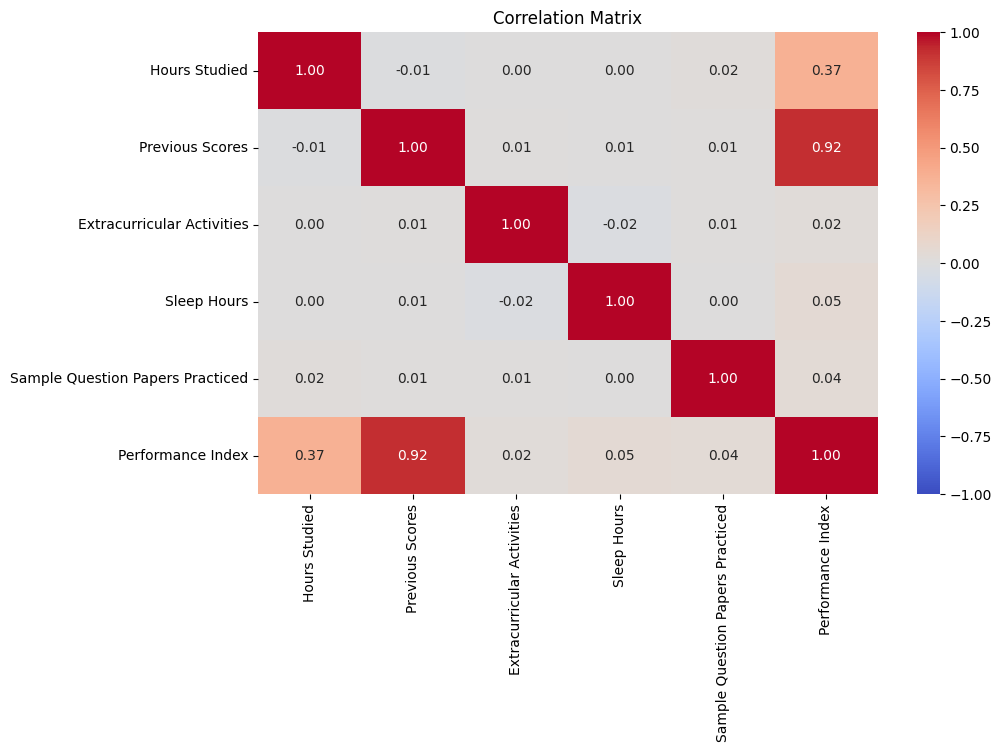

In [30]:
numerical_cols = df.select_dtypes(include=['number']).columns
correlation = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()


## **4.2. Histogram**

alasan saya untuk melihat data menggunakan Histogram adalah

1. untuk melihat sebarang variable Target(Performance Index)
*   bentuk distribusinya membentuk kurva lonceng yang lumayan simetris(distribusi normal/near-normal
*   Interpretasinya seperti yang bisa kita lihat bahwa nilai performa siswa terpusat di area tengah sekitar 40 sampai 80 dengan sedikit siswa yang nilainya sangat rendah yaitu (<20) atau sangat tinggi (>90). menurut saya ini sangat bagus untuk model regresi karena data target tidak dominan (moncong) ke salah satu sisi

2. sebaran variable feature(X)
*   Hour Studied 1 sampai 9 jam
    *   bentuk sebarannya merata
    * interpretasi yang bisa kita lihat bahwa jumlah sample siswa yang belajar 1 jam, 2 jam, hingga 9 jam jumlahnya relatif seimbang
* Previous Scores 40 sampai 99:
    * sebarannya juga merata
    * interpretasi yang dapat kita lihat nilai ujian sebelumnya tersebar cukup adil di seluruh rentang dari 40 sampai 100, tanpa ada penumpukan di salah satu nilai
* Sleep Hours 4 sampai 9 jam dan sample question papers practiced nya 0 sampai 9 paket
    * sebarannya juga merata
    * interpretasi seperti yang bisa kitalihat variable diskrit ini juga terdistribusi secara konsisten dan merata di setiap nilainya

* Extracurricular Activities (0 dan 1)
    * bentuknya bimodal atau Categorical binary Distibution
    * interpretasinya yaitu jumlah siswa yang ikut eskul(1) dan tidak (0) memiliki proporsi yang seimbang masing masing kira kira 50% yang artinya dataset balance pada variable ini



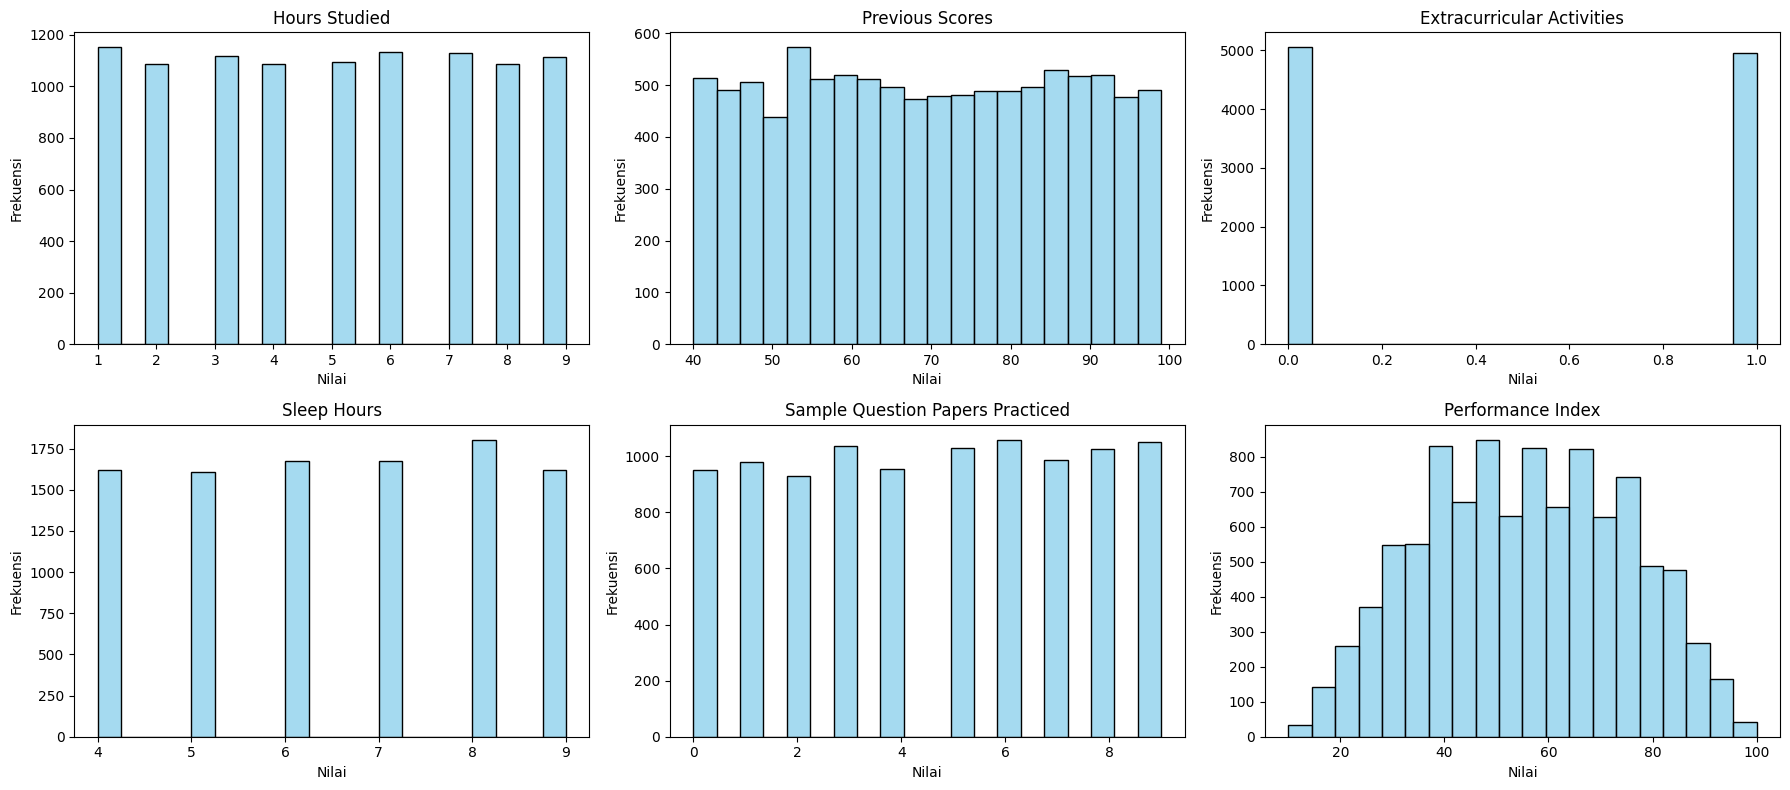

In [31]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    ### MULAI CODE ###

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df[column], bins=20, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

    ### SELESAI CODE ###

plt.tight_layout()
plt.show()

# **5. Train, Test, Split Data**

memisahkan Target dengan Feature

In [32]:
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

In [33]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [34]:
y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


spliting dengan rasio size 80% untuk training dan 20% untuk testing dan mengunci hasil acak 42

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cek hasil spliting

In [36]:
X_train.shape, y_train.shape

((8000, 5), (8000,))

In [37]:
X_test.shape, y_test.shape

((2000, 5), (2000,))

# **6. Membuat Regression dengan  menggunakan model Random Forest**

In [38]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [39]:
y_pred = model.predict(X_test)

# **7. Feature Importance**

In [40]:
X.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced'],
      dtype='object')

In [41]:
print(model.feature_importances_)

[0.14187822 0.84680212 0.00134103 0.00483284 0.0051458 ]


# **8. Performance Model**

* R2Score:  0.9861 (98.61%)
  *   artinya model berhasil menjelaskan 98.61% pattern data nilai siswa. tinggal ggal sisa 1.39% lainnya di pengaruhi oleh faktor acak yang tidak ada di dataset. angka yang model dapatkan disini  mendekati 100% atau 1 menunjukan model memiliki daya prediksi yang baik dan presisi

* MAE (Mean Absolute Error): 1.8093
  * artinya rata rata kesalagan tebakan model itu hanya 1.8.
  artinya jika nilai asli siswa 80 maka model akan memprediksi di kisaran 78,2 sampai 81.8. kesalahan sebesar 1.8 pada rentang nilai skala 0 sampai 100 tergolong sangat kecil dan akurat

* RMSE (Root Mean Squared Error): 2.2660
  *artinya: mengukur rata-rata error dengan memberi bobot lebih berat pada kesalahan yang besar(outlier). nilaunya 2.2660(tidak berbeda jaug dari MAE). artinya selish yang dekat antara RMSE (2.26) dan MAE (1.80) memnunjukan bahwa model sudah konsisten dan tidak pernah melakukan tebakan yang melenceng sangat jauh/ekstrem pada uji mana pun


In [42]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== EVALUASI MODEL RANDOM FOREST ===")
print(f"R2 Score : {r2:.4f} (atau {r2*100:.2f}%)")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

=== EVALUASI MODEL RANDOM FOREST ===
R2 Score : 0.9860 (atau 98.60%)
MAE      : 1.8218
RMSE     : 2.2767


# **9 .Visualisasi Performa Model**

saya menggunakan Scatter Plot (Aktual vs Prediksi)
  * Garis merah ($y = x$) menggambarkan kondisi "prediksi sempurna" (di mana Nilai Prediksi = Nilai Asli). Titik-titik biru adalah data hasil tebakan modelmu. artinya Karena titik-titik biru menempel sangat rapat mengekor garis merah, secara visual terbukti bahwa tebakan model sangat presisi dengan nilai riilnya.

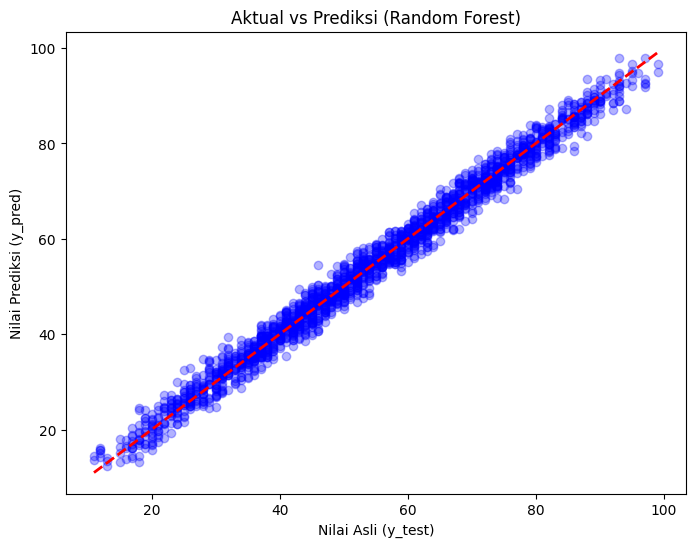

In [43]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis ideal
plt.xlabel('Nilai Asli (y_test)')
plt.ylabel('Nilai Prediksi (y_pred)')
plt.title('Aktual vs Prediksi (Random Forest)')
plt.show()

# **10. Save Model**

simpan model dengan format pkl

In [45]:
import pickle

nama_file = 'Model_Tugas_M2.pkl'

with open(nama_file, 'wb') as file:
    pickle.dump(model, file)

print(f"Model berhasil disimpan dengan nama: {nama_file}")

Model berhasil disimpan dengan nama: Model_Tugas_M2.pkl
